# Exposing the compressor nonlinearity (Ableton ideal-compressor dataset)

The Ableton counterpart of `eval_output_transformer_nonlinearity.ipynb`, applied
to the **Ableton ideal compressor** dataset (60 songs, a *single* parameter
setting `ableton_compressed`). Because there is only one setting, the analysis is
grouped **per song** — over the **validation songs** of the same song-level
train/val split used by `train_lstm_nocond_discretized_ableton.ipynb` (seed 42,
80/20) — exactly as in `eval_ableton_h1_coherence.ipynb`.

In that companion coherence notebook the gain-matched magnitude-squared coherence
sat at ~0.99 for every song — **not** because the compressor is linear, but
because ordinary coherence is the wrong lens for it.

A compressor is, to first order, a **slowly time-varying broadband real gain**
`g(t)`. Within one short STFT window the wet is `Y(f) ≈ g·X(f)` — a scalar,
frequency-flat multiple of the input — so at the per-bin / matched-time level the
dry→wet relation is almost perfectly *linear*, and `γ² → 1`. The nonlinearity
lives in **how `g(t)` is driven by the signal envelope** and in the harmonic
coloration it adds, neither of which a two-signal linear coherence can see.

This notebook reuses the **exact same dataset split and streaming machinery** as
the Ableton coherence notebook and applies the four measures that *do* surface the
nonlinearity:

1. **Best-linear-model residual / NMSE** — fraction of output power that *no*
   per-frequency LTI filter can explain `= Σ Syy(1−γ²) / Σ Syy`. (True test-tone
   THD is not measurable here — this is recorded program material, no controlled
   sines run through the box — so this model-based residual is the data-driven
   analogue.)
2. **Gain-matched residual spectrum** — apply the known broadband GR envelope
   `g(t)`, then look at the spectrum of `r = wet − g·dry`. With the level/dynamics
   removed, what remains is the residual **coloration + harmonic distortion**.
3. **Envelope multiple-coherence** — add the envelope-modulated input `m = g·dry`
   as a *second* regressor and compute the multiple coherence `γ²_{y:x,m}`. The
   **gap** over ordinary coherence is the output power explained only by the
   time-varying gain — a direct signature of the envelope-driven nonlinearity.
4. **Bicoherence** — a higher-order (third-moment) spectrum that detects
   **quadratic phase coupling**. Output bicoherence elevated above input
   bicoherence is unambiguous nonlinearly-generated structure.

All STFT framing uses **librosa**, matching the coherence notebook. An *ideal*
(digital) Ableton compressor should show these nonlinearity read-outs much smaller
than a real analog box would — that contrast is the point of running them here.


In [ ]:
import os
import sys
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

# Resolve repo root robustly (not dependent on where the notebook is launched from)
REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)

# `eval_helpers` (pairs / split / segment readers) lives in 03_initial_GR_pred;
# `amplitude_match` (GR envelope -> linear gain) lives in 06_output.
sys.path.insert(0, str(REPO_ROOT / "06_output"))
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred"))

from amplitude_match import GR_DB_MIN, GR_DB_MAX, gr_db_to_gain
from src.dsp_torch import windowed_rms
from eval_helpers import (
    same_setting_pairs,
    _validation_pairs_from_training_split,
    _song_from_dry_path,
    _read_dry_wet_segment,
    _pair_num_frames,
)

print(f"repo    : {REPO_ROOT}")
print(f"torch   : {torch.__version__}")
print(f"librosa : {librosa.__version__}")

In [ ]:
# Diff-SSL-G-Comp / Ableton ideal-compressor split
DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
SETTING = "ableton_compressed"   # the single Ableton setting
SAMPLE_RATE = 44100

# Song-level split — identical to train_lstm_nocond_discretized_ableton.ipynb.
SPLIT_SEED = 42
TRAIN_SPLIT = 0.8

# Streaming chunk (memory bound); STFT is computed per chunk and accumulated.
STREAM_CHUNK_SEC = 10.0

# --- STFT / spectral-averaging parameters (librosa) ---
N_FFT = 4096
HOP_LENGTH = N_FFT // 4
WINDOW = "hann"
EPS = 1e-12

# Set to a small integer for smoke tests (limits songs evaluated)
MAX_EVAL_SONGS = None

assert os.path.isdir(DATA_ROOT), f"Missing DATA_ROOT: {DATA_ROOT}"
assert os.path.isdir(os.path.join(DATA_ROOT, "gr_curves", SETTING)), \
    f"Missing gr_curves/{SETTING} folder"

# (dry, wet) pairs for the single Ableton setting, then keep the validation songs.
all_pairs = same_setting_pairs(DATA_ROOT, SETTING)
val_pairs = _validation_pairs_from_training_split(
    all_pairs, {"split_seed": SPLIT_SEED, "train_split": TRAIN_SPLIT}
)

# song -> (dry_path, wet_path); SONGS = the validation songs (the "used portion").
SONG_PATHS = {_song_from_dry_path(d): (d, w) for d, w in val_pairs}
SONGS = sorted(SONG_PATHS)
if MAX_EVAL_SONGS is not None:
    SONGS = SONGS[:MAX_EVAL_SONGS]
    SONG_PATHS = {s: SONG_PATHS[s] for s in SONGS}

print(f"Total (dry,wet) pairs : {len(all_pairs)}")
print(f"Validation songs       : {len(SONGS)}")
for s in SONGS:
    print(f"  - {s}")

chunk_frames = int(round(STREAM_CHUNK_SEC * SAMPLE_RATE))
FREQS = librosa.fft_frequencies(sr=SAMPLE_RATE, n_fft=N_FFT)
print(f"\nn_fft={N_FFT}, hop={HOP_LENGTH} -> {len(FREQS)} freq bins")

Validation split: 12 validation songs, 48 train songs (seed=42, train_split=0.8)
Validation songs: ['ALittleLate', 'APictureOfShit', 'AReasonToLeave', 'ASailorOnceMore', 'AccessDenied', 'AmorQueLucha', 'AnotherLife', 'AnotherLife2', 'Attention', 'Bankroll', 'CanYouSayTheSame', 'CatchTheWave']
Total (dry,wet) pairs : 60
Validation songs       : 12
  - ALittleLate
  - APictureOfShit
  - AReasonToLeave
  - ASailorOnceMore
  - AccessDenied
  - AmorQueLucha
  - AnotherLife
  - AnotherLife2
  - Attention
  - Bankroll
  - CanYouSayTheSame
  - CatchTheWave

n_fft=4096, hop=1024 -> 2049 freq bins


## Shared one-pass accumulator

A single streaming pass per **song** computes the STFTs of the **dry** `X`, the
**wet** `Y`, and the **gain-matched** `M = g·dry`, and accumulates every Welch
sum the four measures need:

* `Sxx, Syy, Smm` — auto-spectra,
* `Sxy, Sxm, Smy` — cross-spectra,
* `Srr = Σ|Y − M|²` — the gain-matched residual auto-spectrum (STFT is linear, so
  `STFT(wet − g·dry) = Y − M`).

From these: §1 coherence/NMSE (`Sxx,Syy,Sxy`), §2 residual (`Srr,Syy`), §3
multiple coherence (the full 2-input cross-spectral matrix).

In [ ]:
def pair_paths(song: str) -> tuple[str, str, str]:
    """(dry, wet, gr) paths for one validation song."""
    dry_path, wet_path = SONG_PATHS[song]
    gr_path = os.path.join(DATA_ROOT, "gr_curves", SETTING, f"{song}.pt")
    return dry_path, wet_path, gr_path


def _stft(sig: np.ndarray) -> np.ndarray:
    return librosa.stft(
        np.ascontiguousarray(sig, dtype=np.float32),
        n_fft=N_FFT, hop_length=HOP_LENGTH, window=WINDOW, center=False,
    )


class NLAccumulator:
    """Welch sums for the dry (X), wet (Y) and gain-matched (M) signals."""

    def __init__(self, n_bins: int):
        self.Sxx = np.zeros(n_bins, np.float64)
        self.Syy = np.zeros(n_bins, np.float64)
        self.Smm = np.zeros(n_bins, np.float64)
        self.Sxy = np.zeros(n_bins, np.complex128)
        self.Sxm = np.zeros(n_bins, np.complex128)
        self.Smy = np.zeros(n_bins, np.complex128)
        self.Srr = np.zeros(n_bins, np.float64)   # |Y - M|^2
        self.n_frames = 0

    def add(self, x, y, m):
        if min(len(x), len(y), len(m)) < N_FFT:
            return
        X, Y, M = _stft(x), _stft(y), _stft(m)
        self.Sxx += np.sum(np.abs(X) ** 2, axis=1)
        self.Syy += np.sum(np.abs(Y) ** 2, axis=1)
        self.Smm += np.sum(np.abs(M) ** 2, axis=1)
        self.Sxy += np.sum(np.conj(X) * Y, axis=1)
        self.Sxm += np.sum(np.conj(X) * M, axis=1)
        self.Smy += np.sum(np.conj(M) * Y, axis=1)
        self.Srr += np.sum(np.abs(Y - M) ** 2, axis=1)
        self.n_frames += X.shape[1]

    # §1 -----------------------------------------------------------------
    def coherence(self):
        return (np.abs(self.Sxy) ** 2) / (self.Sxx * self.Syy + EPS)

    def linear_unexplained(self):
        """Per-bin output power fraction no LTI filter can explain = 1 - gamma^2."""
        return 1.0 - self.coherence()

    # §2 -----------------------------------------------------------------
    def distortion_ratio(self):
        """Gain-matched residual / output power, per bin (linear ratio)."""
        return self.Srr / (self.Syy + EPS)

    # §3 -----------------------------------------------------------------
    def multiple_coherence(self, ridge=1e-9):
        """gamma^2_{y:(x,m)} via per-bin 2x2 cross-spectral solve."""
        a = self.Sxx + ridge
        d = self.Smm + ridge
        b = self.Sxm                     # c = conj(b)
        det = a * d - np.abs(b) ** 2 + EPS
        p, q = self.Sxy, self.Smy        # b_vec = [Sxy, Smy]
        inv0 = (d * p - b * q) / det                 # (Sxx^-1 b_vec)[0]
        inv1 = (-np.conj(b) * p + a * q) / det       # (Sxx^-1 b_vec)[1]
        num = np.real(np.conj(p) * inv0 + np.conj(q) * inv1)
        return np.clip(num / (self.Syy + EPS), 0.0, 1.0)


@torch.no_grad()
def accumulate_song(song: str, acc: NLAccumulator) -> None:
    """Stream one validation song into the dry/wet/gain-matched accumulator."""
    dry_path, wet_path, gr_path = pair_paths(song)
    gr_obj = torch.load(gr_path, weights_only=False, map_location="cpu")
    gr_db_full = gr_obj["gr_db"].float()
    if gr_db_full.ndim == 1:
        gr_db_full = gr_db_full.unsqueeze(0)
    if gr_db_full.shape[0] > 1:
        gr_db_full = gr_db_full.mean(dim=0, keepdim=True)

    total = min(_pair_num_frames(dry_path, wet_path, SAMPLE_RATE), gr_db_full.shape[-1])
    for o in range(0, total, chunk_frames):
        stop = min(o + chunk_frames, total)
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, SAMPLE_RATE)
        L = min(dry.shape[-1], wet.shape[-1])
        if L < N_FFT:
            continue
        dry, wet = dry[..., :L], wet[..., :L]
        gr_db = gr_db_full[..., o : o + L].clamp(GR_DB_MIN, GR_DB_MAX)
        matched = dry * gr_db_to_gain(gr_db, clamp=False)
        acc.add(dry.squeeze(0).numpy(), wet.squeeze(0).numpy(), matched.squeeze(0).numpy())
    gc.collect()


# Run the single pass per song.
results = {}
for si, song in enumerate(SONGS, start=1):
    acc = NLAccumulator(len(FREQS))
    print(f"[{si}/{len(SONGS)}] {song}")
    accumulate_song(song, acc)
    results[song] = {"acc": acc}

print("\nFrames per song:")
for song in SONGS:
    print(f"  {song:32s} {results[song]['acc'].n_frames:>8d}")

[1/12] ALittleLate
[2/12] APictureOfShit
[3/12] AReasonToLeave
[4/12] ASailorOnceMore
[5/12] AccessDenied
[6/12] AmorQueLucha
[7/12] AnotherLife
[8/12] AnotherLife2
[9/12] Attention
[10/12] Bankroll
[11/12] CanYouSayTheSame
[12/12] CatchTheWave

Frames per song:
  ALittleLate                          8353
  APictureOfShit                      12724
  AReasonToLeave                      11026
  ASailorOnceMore                      8881
  AccessDenied                        12480
  AmorQueLucha                        12058
  AnotherLife                         12537
  AnotherLife2                        10324
  Attention                            8678
  Bankroll                             9726
  CanYouSayTheSame                    10072
  CatchTheWave                        11102


In [ ]:
F_MIN, F_MAX = 20.0, SAMPLE_RATE / 2
fmask = (FREQS >= F_MIN) & (FREQS <= F_MAX)
band = (FREQS >= 200) & (FREQS <= 8000)          # broadband summary band
cmap = plt.get_cmap("viridis", len(SONGS))


def short_label(song: str) -> str:
    return song


# Order songs by how nonlinear they are: highest best-LTI NMSE first
# (largest share of the wet that no fixed linear filter of the dry can reproduce).
def nonlinearity_score(song: str) -> float:
    acc = results[song]["acc"]
    return float(
        np.sum(acc.Syy[band] * acc.linear_unexplained()[band]) / (np.sum(acc.Syy[band]) + EPS)
    )


SONGS_BY_NL = sorted(SONGS, key=nonlinearity_score, reverse=True)
MOST_NL = SONGS_BY_NL[0]
print(f"Most nonlinear song (by best-LTI NMSE): {MOST_NL}")

Most nonlinear song (by best-LTI NMSE): Bankroll


## §1 — Best-linear-model residual / NMSE

For every frequency bin the **optimal** per-bin LTI transfer is `H1 = Sxy/Sxx`;
the output power it leaves unexplained is `Syy·(1−γ²)`. Summed over the band this
is the **NMSE of the best linear time-invariant model** — the share of the wet
that *no* fixed filter of the dry can reproduce. For a truly linear box this
floors near the recording noise; a compressor pushes it up.

`true test-tone THD is not available on program material` — this NMSE is its
data-driven stand-in. Curves below: `10·log10(1−γ²)` per frequency (higher = more
non-LTI energy).

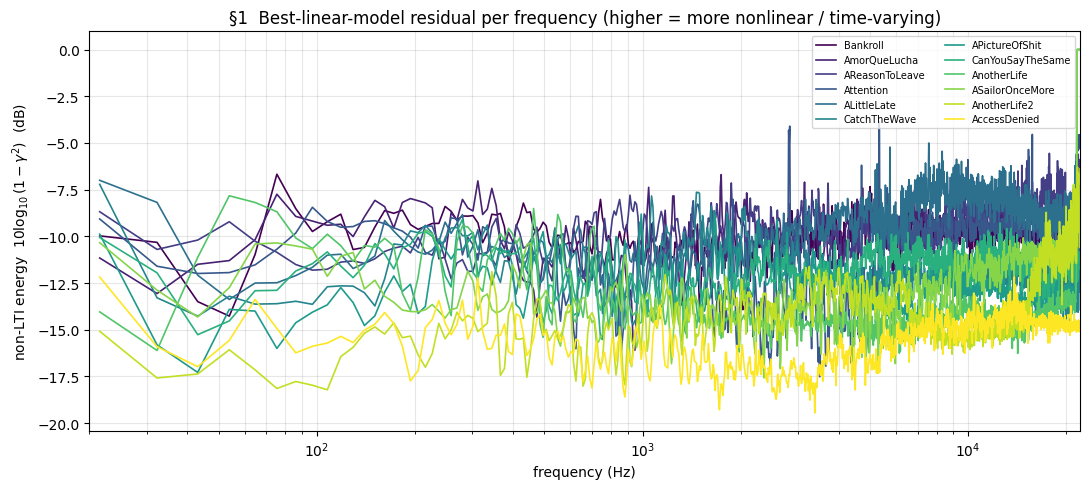

Broadband (200 Hz-8 kHz) best-LTI NMSE, ordered most -> least nonlinear:
  Bankroll                            NMSE =   -9.86 dB
  AmorQueLucha                        NMSE =  -10.12 dB
  AReasonToLeave                      NMSE =  -10.71 dB
  Attention                           NMSE =  -10.88 dB
  ALittleLate                         NMSE =  -10.92 dB
  CatchTheWave                        NMSE =  -11.26 dB
  APictureOfShit                      NMSE =  -11.76 dB
  CanYouSayTheSame                    NMSE =  -11.76 dB
  AnotherLife                         NMSE =  -12.04 dB
  ASailorOnceMore                     NMSE =  -13.54 dB
  AnotherLife2                        NMSE =  -14.89 dB
  AccessDenied                        NMSE =  -16.38 dB


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for i, song in enumerate(SONGS_BY_NL):
    acc = results[song]["acc"]
    unexp_db = 10 * np.log10(acc.linear_unexplained() + EPS)
    ax.semilogx(FREQS[fmask], unexp_db[fmask], lw=1.2, color=cmap(i), label=short_label(song))
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"non-LTI energy  $10\log_{10}(1-\gamma^2)$  (dB)")
ax.set_title("§1  Best-linear-model residual per frequency (higher = more nonlinear / time-varying)")
ax.set_xlim(F_MIN, F_MAX)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()

print("Broadband (200 Hz-8 kHz) best-LTI NMSE, ordered most -> least nonlinear:")
for song in SONGS_BY_NL:
    acc = results[song]["acc"]
    nmse = np.sum(acc.Syy[band] * acc.linear_unexplained()[band]) / (np.sum(acc.Syy[band]) + EPS)
    print(f"  {short_label(song):34s}  NMSE = {10*np.log10(nmse + EPS):7.2f} dB")

## §2 — Gain-matched residual spectrum

Remove the compressor's level/dynamics with the **known** broadband GR envelope
`g(t)` (the grey-box front-end used across this project), then inspect the
spectrum of the leftover `r = wet − g·dry`. A pure broadband gain would leave
`r ≈ 0`; what actually remains is the compressor's frequency-dependent
**coloration + harmonic distortion**. Curves: residual-to-output ratio
`10·log10(Srr/Syy)` per frequency.

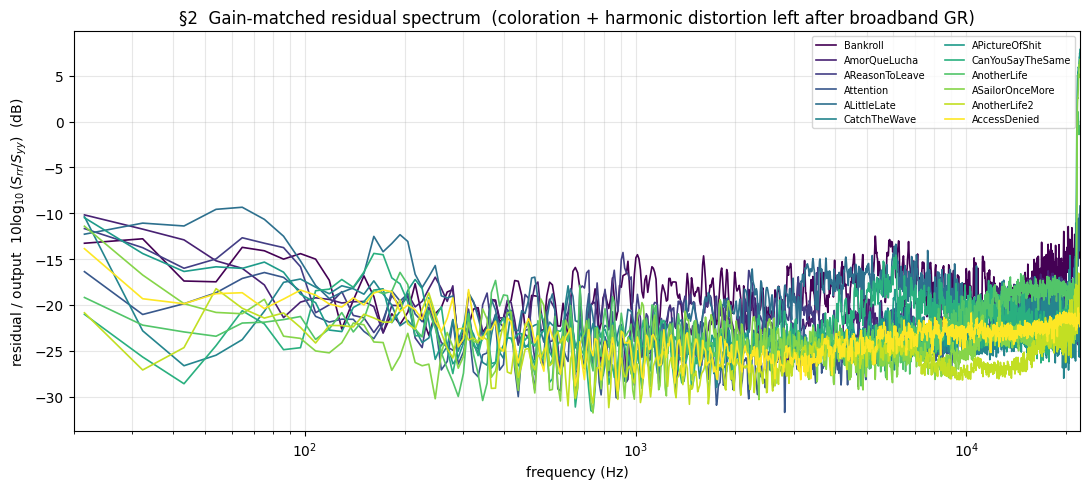

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for i, song in enumerate(SONGS_BY_NL):
    acc = results[song]["acc"]
    dr_db = 10 * np.log10(acc.distortion_ratio() + EPS)
    ax.semilogx(FREQS[fmask], dr_db[fmask], lw=1.2, color=cmap(i), label=short_label(song))
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel(r"residual / output  $10\log_{10}(S_{rr}/S_{yy})$  (dB)")
ax.set_title("§2  Gain-matched residual spectrum  (coloration + harmonic distortion left after broadband GR)")
ax.set_xlim(F_MIN, F_MAX)
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()

### Listen — gain-matched residual

The residual `r = wet − g·dry` removes the compressor's broadband level/dynamics
and leaves only its **frequency-dependent coloration + harmonic distortion** —
which you can now hear.

The broadband gain is estimated from the **windowed RMS envelopes** (same
1024-sample window as the project's GR export):

`gr_db(t) = 20·log10 RMS(wet) − 20·log10 RMS(dry)`,  then  `g(t) = 10^(gr_db/20)`.

The figure shows the dry/wet RMS envelopes in dBFS (top), the GR curve
`wet − dry` (middle), and the dry / wet / gain-matched /
peak-normalized-residual waveforms (bottom). The audio players use the same excerpt;
dry, wet and gain-matched share one scale, while the **residual is peak-normalized**
because it is much quieter than the output (see the printed residual/output dB).
**Note:** this on-the-fly RMS GR differs from §2, whose spectral residual uses
the project's precomputed GR curve.


In [ ]:
# ---- Listen to the gain-matched residual  r = wet − g·dry  (the audible nonlinearity) ----
from IPython.display import Audio, display
from src.dsp_torch import gain_reduction_db, RMS_WINDOW

LISTEN_SECONDS = 3.0      # excerpt length rendered as audio players
LISTEN_OFFSET_SEC = 32.0   # skip in to land on musical material (clamped to fit the file)

# GR = windowed RMS envelope difference in dB (same as the project GR export),
#   gr_db(t) = 20·log10 RMS(wet) − 20·log10 RMS(dry),
# then the gain-matched signal is g·dry with g = 10^(gr_db/20).


def _clamp_offset(offset_sec, total, seconds):
    o = int(round(offset_sec * SAMPLE_RATE))
    return min(o, max(total - int(round(seconds * SAMPLE_RATE)), 0))


def _to_1d(signal: torch.Tensor) -> torch.Tensor:
    x = signal.float()
    while x.ndim > 1:
        x = x.squeeze(0)
    return x


def rms_envelope_db(signal: torch.Tensor, window: int = RMS_WINDOW) -> torch.Tensor:
    """Windowed RMS envelope in dBFS."""
    rms = windowed_rms(_to_1d(signal), window)
    return 20 * torch.log10(rms.clamp(min=1e-10))


def residual_excerpt(song, seconds=LISTEN_SECONDS, offset_sec=LISTEN_OFFSET_SEC):
    """Time-domain dry / wet / gain-matched / residual (wet − g·dry) excerpt for one song.
    GR = RMS_dB(wet) − RMS_dB(dry); g = 10^(gr_db/20)."""
    dry_path, wet_path, _ = pair_paths(song)
    total = _pair_num_frames(dry_path, wet_path, SAMPLE_RATE)
    o = _clamp_offset(offset_sec, total, seconds)
    stop = min(o + int(round(seconds * SAMPLE_RATE)), total)
    dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, SAMPLE_RATE)
    L = min(dry.shape[-1], wet.shape[-1])
    d, y = _to_1d(dry[..., :L]), _to_1d(wet[..., :L])
    gr_db = gain_reduction_db(d, y, RMS_WINDOW).clamp(GR_DB_MIN, GR_DB_MAX)
    dry_db = rms_envelope_db(d)
    wet_db = rms_envelope_db(y)
    matched = d * gr_db_to_gain(gr_db, clamp=False)
    res = y - matched
    sq = lambda t: t.detach().numpy()
    return sq(d), sq(y), sq(matched), sq(res), sq(gr_db), sq(dry_db), sq(wet_db)


def plot_residual_time_domain(dry, wet, matched, res, gr_db, dry_db, wet_db, title=None):
    """RMS dB envelopes, GR curve and residual waveform for the excerpt."""
    t = np.arange(len(dry)) / SAMPLE_RATE
    fig, (ax_env, ax_gr, ax_res) = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)

    ax_env.plot(t, dry_db, color="0.45", lw=0.8, label="dry RMS (dBFS)")
    ax_env.plot(t, wet_db, color="C1", lw=0.8, label="wet RMS (dBFS)")
    ax_env.set_ylabel("level (dBFS)")
    ax_env.set_title(
        f"{title or 'excerpt'} — RMS dB envelopes ({RMS_WINDOW}-sample window), "
        f"GR = wet−dry & residual"
    )
    ax_env.legend(loc="lower right", fontsize=8, ncol=2)
    ax_env.grid(True, alpha=0.25)

    ax_gr.plot(t, gr_db, color="C0", lw=0.8)
    ax_gr.axhline(0, color="0.75", lw=0.6)
    ax_gr.set_ylabel("GR (dB)")
    ax_gr.grid(True, alpha=0.25)

    shared = max(np.max(np.abs(dry)), np.max(np.abs(wet)), np.max(np.abs(matched)), EPS)
    rpk = max(np.max(np.abs(res)), EPS)
    ax_res.plot(t, dry / shared, color="0.55", lw=0.5, alpha=0.8, label="dry  x")
    ax_res.plot(t, wet / shared, color="C1", lw=0.5, alpha=0.8, label="wet  y")
    ax_res.plot(t, matched / shared, color="C2", lw=0.5, alpha=0.8, label="g·x  (gain-matched)")
    ax_res.plot(t, res / rpk, color="C3", lw=0.7, label="residual  r = y − g·x  (peak-norm.)")
    ax_res.set_xlabel("time (s)")
    ax_res.set_ylabel("amplitude")
    ax_res.legend(loc="upper right", fontsize=8, ncol=2)
    ax_res.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


def play_residual(item, title=None):
    """Render dry / wet / gain-matched / residual audio players for one item."""
    dry, wet, matched, res, gr_db, dry_db, wet_db = residual_excerpt(item)
    rms = lambda a: float(np.sqrt(np.mean(a ** 2)) + EPS)
    print(f"{title or item}")
    print(
        f"  GR = RMS_dB(wet) − RMS_dB(dry), {RMS_WINDOW}-sample window "
        f"(dry min {dry_db.min():.1f} dB, wet min {wet_db.min():.1f} dB)"
    )
    print(f"  residual/output = {20*np.log10(rms(res)/rms(wet)):5.1f} dB   "
          f"(peaks: wet {np.max(np.abs(wet)):.3f}, residual {np.max(np.abs(res)):.4f})")
    plot_residual_time_domain(dry, wet, matched, res, gr_db, dry_db, wet_db, title=title or item)
    shared = max(np.max(np.abs(dry)), np.max(np.abs(wet)), np.max(np.abs(matched)), EPS)
    rpk = max(np.max(np.abs(res)), EPS)
    for name, sig, sc in [
        ("dry  x", dry, shared),
        ("wet  y", wet, shared),
        ("gain-matched  g·x   (broadband GR removed)", matched, shared),
        ("residual  r = y − g·x   [peak-normalized — the audible nonlinearity]", res, rpk),
    ]:
        print("  " + name)
        display(Audio(sig / sc, rate=SAMPLE_RATE, normalize=False))


# Listen to the most nonlinear song (set to any name in SONGS_BY_NL).
play_residual(SONGS_BY_NL[0])


In [ ]:
# ---- Experiment: pointwise (wet/dry) GR vs windowed-RMS envelope GR ----
# Two ways to estimate the broadband gain g(t) and the residual r = wet - g·dry:
#   (A) pointwise   g = wet/dry   (instantaneous; regularized at zero-crossings)
#   (B) RMS env     gr_db = 20log10 RMS(wet) - 20log10 RMS(dry)
# (A) drives the residual to ~0 but only *trivially*: a per-sample gain can reproduce ANY
# wet from a non-zero dry, so its GR curve is meaningless noise (it spikes at every
# zero-crossing). (B) constrains g to vary slowly -> a readable GR, but it cannot follow
# the 1 ms attack inside its window, so the residual keeps the transient bleed.

CMP_RMS_WIN = 64                       # window for the "normal RMS version"
CMP_AMP_FLOOR = 1e-10  # RMS / pointwise regularization floor (linear)
CMP_SONG = SONGS_BY_NL[0]


def _gr_experiment(song, seconds=LISTEN_SECONDS, offset_sec=LISTEN_OFFSET_SEC, rms_win=CMP_RMS_WIN):
    dry_path, wet_path, _ = pair_paths(song)
    total = _pair_num_frames(dry_path, wet_path, SAMPLE_RATE)
    o = _clamp_offset(offset_sec, total, seconds)
    stop = min(o + int(round(seconds * SAMPLE_RATE)), total)
    dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, stop, SAMPLE_RATE)
    L = min(dry.shape[-1], wet.shape[-1])
    d, y = _to_1d(dry[..., :L]), _to_1d(wet[..., :L])

    # (A) pointwise division  g = wet/dry  (= wet·dry/(dry²+ε): exact where |dry|≫floor, →0 at dry→0)
    eps = CMP_AMP_FLOOR ** 2
    g_pt = y * d / (d * d + eps)
    gr_pt = (20 * torch.log10(g_pt.abs().clamp(min=CMP_AMP_FLOOR))).clamp(GR_DB_MIN, GR_DB_MAX)
    res_pt = y - gr_db_to_gain(gr_pt, clamp=False) * d

    # (B) windowed-RMS envelope difference in dB
    rd = windowed_rms(d, rms_win).clamp(min=CMP_AMP_FLOOR)
    rw = windowed_rms(y, rms_win).clamp(min=CMP_AMP_FLOOR)
    gr_rms = (20 * torch.log10(rw) - 20 * torch.log10(rd)).clamp(GR_DB_MIN, GR_DB_MAX)
    res_rms = y - gr_db_to_gain(gr_rms, clamp=False) * d
    return (d.numpy(), y.numpy(), gr_pt.numpy(), res_pt.numpy(), gr_rms.numpy(), res_rms.numpy())


d, y, gr_pt, res_pt, gr_rms, res_rms = _gr_experiment(CMP_SONG)
yo = float(np.sqrt(np.mean(y ** 2)) + EPS)
rdb = lambda r: 20 * np.log10((np.sqrt(np.mean(r ** 2)) + EPS) / yo)
print(f"{CMP_SONG}")
print(f"  (A) pointwise wet/dry   residual/output = {rdb(res_pt):6.1f} dB   (GR curve is noise — see plot)")
print(f"  (B) RMS env ({CMP_RMS_WIN}-samp)    residual/output = {rdb(res_rms):6.1f} dB   (smooth, usable GR)")

t = np.arange(len(d)) / SAMPLE_RATE
fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
ax[0].plot(t, gr_pt, color="C3", lw=0.4, alpha=0.9, label="(A) pointwise  20log|wet/dry|")
ax[0].plot(t, gr_rms, color="C0", lw=1.0, label=f"(B) RMS env ({CMP_RMS_WIN}-samp)")
ax[0].set_ylabel("GR (dB)"); ax[0].grid(alpha=.3); ax[0].legend(fontsize=8, loc="lower right")
ax[0].set_title(f"{CMP_SONG} — pointwise wet/dry GR vs RMS-envelope GR")

rp = max(np.max(np.abs(res_rms)), EPS)   # shared residual scale
ax[1].plot(t, d / np.max(np.abs(d)), color="0.6", lw=0.4, label="dry (ref)")
ax[1].plot(t, res_pt / rp, color="C3", lw=0.5, label=f"(A) residual  ({rdb(res_pt):.0f} dB)")
ax[1].set_ylabel("pointwise"); ax[1].grid(alpha=.3); ax[1].legend(fontsize=8, loc="upper right")
ax[2].plot(t, d / np.max(np.abs(d)), color="0.6", lw=0.4, label="dry (ref)")
ax[2].plot(t, res_rms / rp, color="C0", lw=0.5, label=f"(B) residual  ({rdb(res_rms):.0f} dB)")
ax[2].set_ylabel("RMS env"); ax[2].grid(alpha=.3); ax[2].legend(fontsize=8, loc="upper right")
ax[2].set_xlabel("time (s)")
plt.tight_layout(); plt.show()


## §3 — Envelope multiple-coherence

Add the envelope-modulated input `m = g·dry` as a **second regressor** and compute
the multiple coherence `γ²_{y:(x,m)}`. Because `g(t)` varies *within* each window,
`STFT(g·x) ≠ g·STFT(x)` — `m` carries genuinely new (modulation-spread) structure,
so the 2×2 cross-spectral matrix is well-conditioned. The **gap**
`γ²_{y:(x,m)} − γ²_{yx}` is the output power explained *only* once the time-varying
gain is admitted — a direct, per-frequency signature of the envelope-driven
nonlinearity. Top: ordinary vs multiple coherence for the most nonlinear song.
Bottom: the gap for every song.

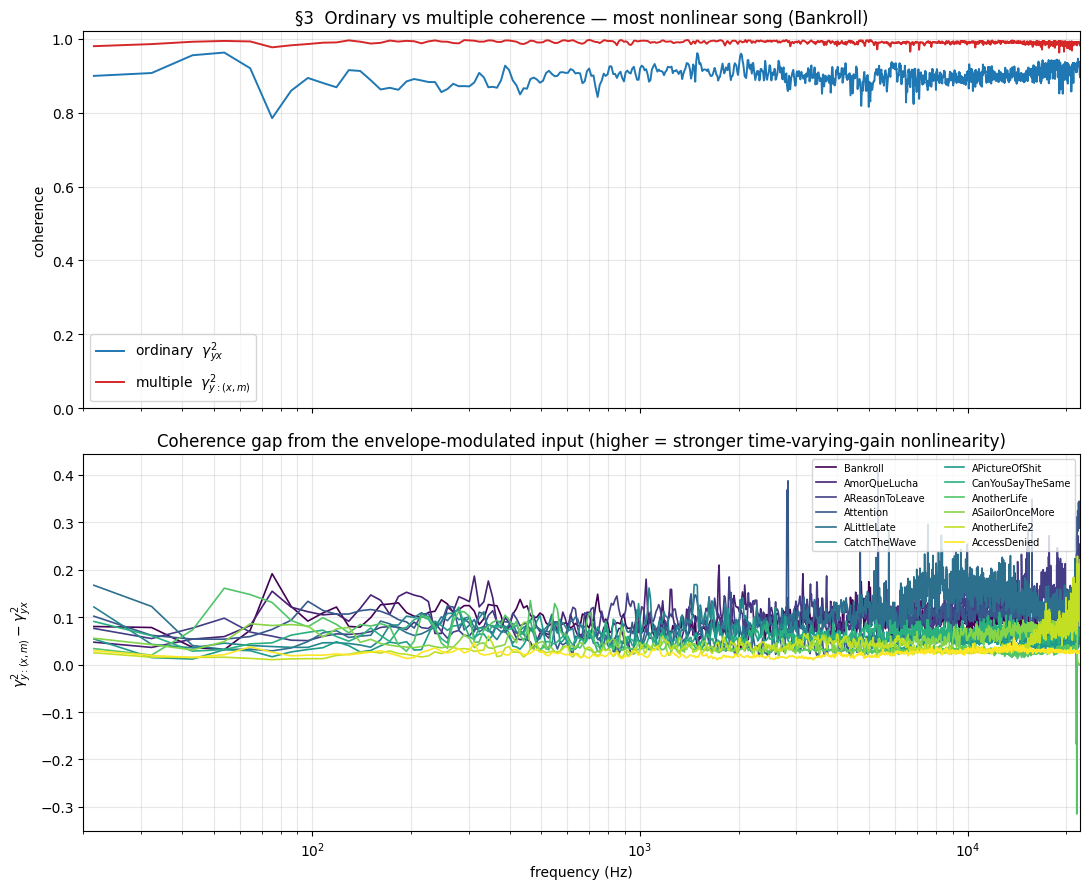

In [ ]:
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

acc_h = results[MOST_NL]["acc"]
ax_top.semilogx(FREQS[fmask], acc_h.coherence()[fmask], lw=1.4,
                color="#1f77b4", label=r"ordinary  $\gamma^2_{yx}$")
ax_top.semilogx(FREQS[fmask], acc_h.multiple_coherence()[fmask], lw=1.4,
                color="#d62728", label=r"multiple  $\gamma^2_{y:(x,m)}$")
ax_top.set_ylabel("coherence")
ax_top.set_ylim(0, 1.02)
ax_top.set_title(f"§3  Ordinary vs multiple coherence — most nonlinear song ({short_label(MOST_NL)})")
ax_top.grid(True, which="both", alpha=0.3)
ax_top.legend(loc="lower left")

for i, song in enumerate(SONGS_BY_NL):
    acc = results[song]["acc"]
    gap = acc.multiple_coherence() - acc.coherence()
    ax_bot.semilogx(FREQS[fmask], gap[fmask], lw=1.2, color=cmap(i), label=short_label(song))
ax_bot.set_xlabel("frequency (Hz)")
ax_bot.set_ylabel(r"$\gamma^2_{y:(x,m)} - \gamma^2_{yx}$")
ax_bot.set_title("Coherence gap from the envelope-modulated input (higher = stronger time-varying-gain nonlinearity)")
ax_bot.set_xlim(F_MIN, F_MAX)
ax_bot.grid(True, which="both", alpha=0.3)
ax_bot.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()

## §4 — Bicoherence (quadratic phase coupling)

The third-order analogue of coherence:

$$b^2(f_1,f_2)=\frac{\left|\;\mathbb{E}\!\left[X(f_1)X(f_2)X^*(f_1{+}f_2)\right]\right|^2}
{\mathbb{E}|X(f_1)X(f_2)|^2\;\cdot\;\mathbb{E}|X(f_1{+}f_2)|^2}.$$

It is ~0 for a linear process with independent-phase components and rises toward 1
where a **quadratic** nonlinearity phase-locks `f_1`, `f_2` and their sum.
Computed on one excerpt of the most nonlinear song, decimated for tractability.
The **wet** map showing structure absent from the **dry** map is
nonlinearly-generated coupling — proof the box is not linear, independent of any
envelope model.

Bicoherence: Bankroll @ ableton_compressed  | 11025 Hz, n_fft=256, 129 bins, excerpt 60s


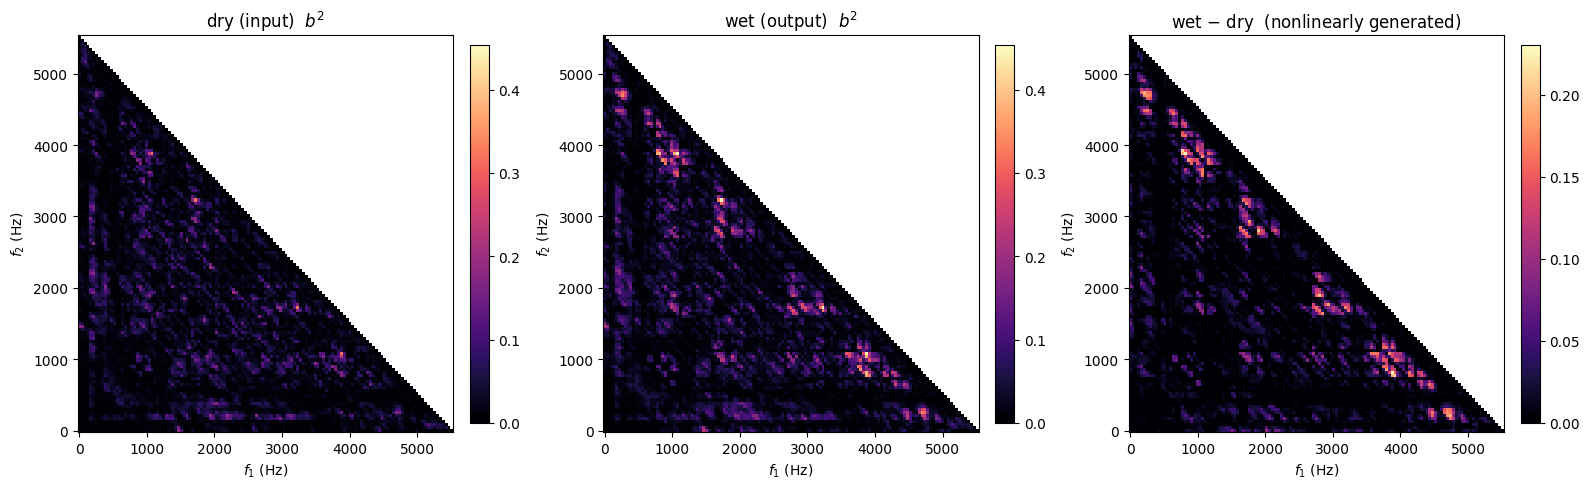

mean bicoherence  dry=0.0243   wet=0.0332   (wet/dry = 1.37x)


In [ ]:
# Decimated, single excerpt of the most nonlinear song (bicoherence is O(F^2)).
BIC_SR = 11025
BIC_NFFT = 256
BIC_HOP = BIC_NFFT // 2
BIC_SONG = MOST_NL
BIC_DUR_SEC = 60.0

_dry_path, _wet_path, _ = pair_paths(BIC_SONG)
_total = _pair_num_frames(_dry_path, _wet_path, SAMPLE_RATE)
_stop = min(_total, int(BIC_DUR_SEC * SAMPLE_RATE))
_dry, _wet = _read_dry_wet_segment(_dry_path, _wet_path, 0, _stop, SAMPLE_RATE)
dry_ds = librosa.resample(_dry.squeeze(0).numpy(), orig_sr=SAMPLE_RATE, target_sr=BIC_SR)
wet_ds = librosa.resample(_wet.squeeze(0).numpy(), orig_sr=SAMPLE_RATE, target_sr=BIC_SR)


def bicoherence(sig, nfft, hop):
    S = librosa.stft(np.ascontiguousarray(sig, np.float32), n_fft=nfft,
                     hop_length=hop, window="hann", center=False)   # [F, T]
    F = S.shape[0]
    idx = np.arange(F)
    s = idx[:, None] + idx[None, :]
    valid = s < F
    s_clip = np.where(valid, s, 0)
    num = np.zeros((F, F), np.complex128)
    d1 = np.zeros((F, F), np.float64)
    d2 = np.zeros((F, F), np.float64)
    for t in range(S.shape[1]):
        Xt = S[:, t]
        prod = np.outer(Xt, Xt)            # X(f1) X(f2)
        Xsum = Xt[s_clip]                  # X(f1+f2)
        num += prod * np.conj(Xsum)
        d1 += np.abs(prod) ** 2
        d2 += np.abs(Xsum) ** 2
    b2 = (np.abs(num) ** 2) / (d1 * d2 + EPS)
    b2[~valid] = np.nan
    return b2, librosa.fft_frequencies(sr=BIC_SR, n_fft=nfft)


b2_dry, bfreq = bicoherence(dry_ds, BIC_NFFT, BIC_HOP)
b2_wet, _ = bicoherence(wet_ds, BIC_NFFT, BIC_HOP)
print(f"Bicoherence: {BIC_SONG} @ {SETTING}  | {BIC_SR} Hz, n_fft={BIC_NFFT}, "
      f"{b2_dry.shape[0]} bins, excerpt {_stop/SAMPLE_RATE:.0f}s")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, data, title in zip(
    axes,
    [b2_dry, b2_wet, b2_wet - b2_dry],
    ["dry (input)  $b^2$", "wet (output)  $b^2$", "wet $-$ dry  (nonlinearly generated)"],
):
    pm = ax.pcolormesh(bfreq, bfreq, data, shading="auto", cmap="magma",
                       vmin=0, vmax=(np.nanmax(b2_wet) if "generated" not in title else None))
    ax.set_title(title)
    ax.set_xlabel("$f_1$ (Hz)")
    ax.set_ylabel("$f_2$ (Hz)")
    fig.colorbar(pm, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print(f"mean bicoherence  dry={np.nanmean(b2_dry):.4f}   wet={np.nanmean(b2_wet):.4f}   "
      f"(wet/dry = {np.nanmean(b2_wet)/ (np.nanmean(b2_dry)+EPS):.2f}x)")

## Summary

Per song (most → least nonlinear), the four nonlinearity read-outs over the
200 Hz–8 kHz band. Ordinary coherence is shown for reference — note how little it
moves while the targeted measures separate the songs. For an ideal digital
compressor these read-outs should stay markedly lower than for a real analog
device.

In [ ]:
rows = []
for song in SONGS_BY_NL:
    acc = results[song]["acc"]
    nmse = np.sum(acc.Syy[band] * acc.linear_unexplained()[band]) / (np.sum(acc.Syy[band]) + EPS)
    rows.append({
        "Song": song,
        "Frames": acc.n_frames,
        "ord. coh (ref)": float(np.mean(acc.coherence()[band])),
        "§1 best-LTI NMSE dB": 10 * np.log10(nmse + EPS),
        "§2 resid/out dB": float(np.mean(10 * np.log10(acc.distortion_ratio()[band] + EPS))),
        "§3 multi-coh gap": float(np.mean((acc.multiple_coherence() - acc.coherence())[band])),
    })
summary_df = pd.DataFrame(rows)
display(summary_df.round(4))

,Song,Frames,ord. coh (ref),§1 best-LTI NMSE dB,§2 resid/out dB,§3 multi-coh gap
0,Bankroll,9726,0.8991,-9.8559,-18.0433,0.0913
1,AmorQueLucha,12058,0.8921,-10.1221,-22.8393,0.1030
2,AReasonToLeave,11026,0.8954,-10.7150,-22.1872,0.0992
3,Attention,8678,0.9259,-10.8802,-24.6509,0.0704
4,ALittleLate,8353,0.8815,-10.9171,-18.5872,0.1062
5,CatchTheWave,11102,0.9315,-11.2552,-24.5904,0.0651
6,APictureOfShit,12724,0.9445,-11.7596,-23.3152,0.0510
7,CanYouSayTheSame,10072,0.9316,-11.7599,-21.7822,0.0625
8,AnotherLife,12537,0.9623,-12.0442,-24.1974,0.0338
9,ASailorOnceMore,8881,0.9559,-13.5358,-25.1510,0.0412
